In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")

print("Imports done")

Imports done


In [3]:
df = pd.read_csv(
    "household_power_consumption.txt",
    sep=';',
    parse_dates={'datetime': ['Date', 'Time']},
    infer_datetime_format=True,
    na_values=['?'],
    low_memory=False
)

print(df.shape)
df.head()

(2075259, 8)


,datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [4]:
print(df.isnull().sum())
print("\nMissing %:", (df['Global_active_power'].isnull().sum() / len(df)) * 100)

datetime                     0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

Missing %: 1.2518437457686005


In [5]:
df = df.set_index('datetime')

df = df.fillna(method='ffill')

print(df.isnull().sum())
df.head()

Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [6]:
df_hourly = df['Global_active_power'].resample('h').mean().to_frame()
df_hourly.columns = ['Global_active_power']

print(df_hourly.shape)
df_hourly.head()

(34589, 1)


,Global_active_power
datetime,
2006-12-16 17:00:00,4.222889
2006-12-16 18:00:00,3.632200
2006-12-16 19:00:00,3.400233
2006-12-16 20:00:00,3.268567
2006-12-16 21:00:00,3.056467


In [7]:
print(df_hourly.shape)
print(df_hourly.isnull().sum())
df_hourly = df_hourly.dropna() 
print("After dropna:", df_hourly.shape)

(34589, 1)
Global_active_power    0
dtype: int64
After dropna: (34589, 1)


In [9]:
df_hourly['hour'] = df_hourly.index.hour
df_hourly['day'] = df_hourly.index.day
df_hourly['month'] = df_hourly.index.month
df_hourly['year'] = df_hourly.index.year
df_hourly['dayofweek'] = df_hourly.index.dayofweek 
df_hourly['is_weekend'] = df_hourly['dayofweek'].isin([5,6]).astype(int)

df_hourly.head()

,Global_active_power,hour,day,month,year,dayofweek,is_weekend
datetime,,,,,,,
2006-12-16 17:00:00,4.222889,17,16,12,2006,5,1
2006-12-16 18:00:00,3.632200,18,16,12,2006,5,1
2006-12-16 19:00:00,3.400233,19,16,12,2006,5,1
2006-12-16 20:00:00,3.268567,20,16,12,2006,5,1
2006-12-16 21:00:00,3.056467,21,16,12,2006,5,1


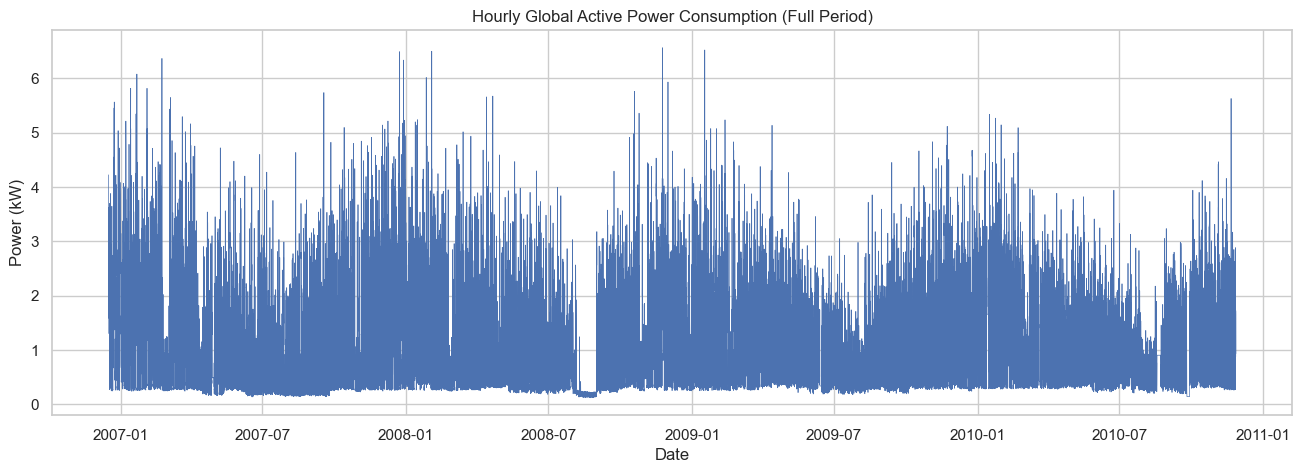

In [10]:
plt.figure(figsize=(16,5))
plt.plot(df_hourly.index, df_hourly['Global_active_power'], linewidth=0.5)
plt.title("Hourly Global Active Power Consumption (Full Period)")
plt.xlabel("Date")
plt.ylabel("Power (kW)")
plt.show()

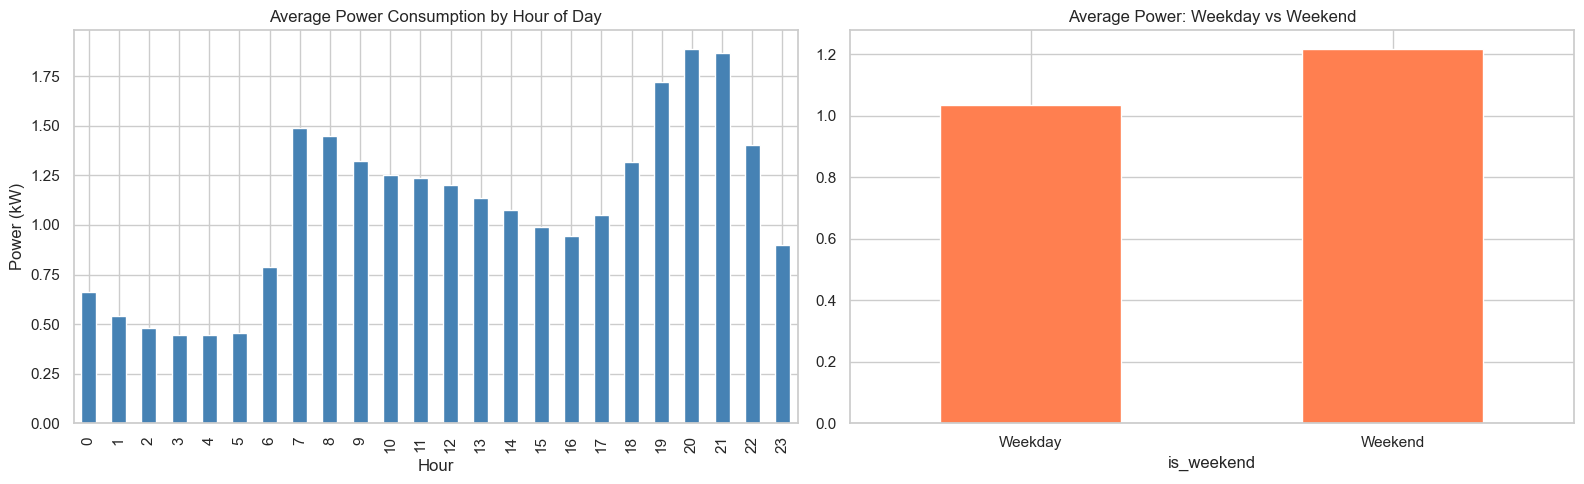

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16,5))

df_hourly.groupby('hour')['Global_active_power'].mean().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title("Average Power Consumption by Hour of Day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Power (kW)")

df_hourly.groupby('is_weekend')['Global_active_power'].mean().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title("Average Power: Weekday vs Weekend")
axes[1].set_xticklabels(['Weekday', 'Weekend'], rotation=0)

plt.tight_layout()
plt.show()

In [12]:
df_recent = df_hourly.last('60D').copy()
print(df_recent.shape)
df_recent.head()

(1440, 7)


,Global_active_power,hour,day,month,year,dayofweek,is_weekend
datetime,,,,,,,
2010-09-27 22:00:00,0.146,22,27,9,2010,0,0
2010-09-27 23:00:00,0.146,23,27,9,2010,0,0
2010-09-28 00:00:00,0.146,0,28,9,2010,1,0
2010-09-28 01:00:00,0.146,1,28,9,2010,1,0
2010-09-28 02:00:00,0.146,2,28,9,2010,1,0


In [13]:
train = df_recent.iloc[:-7*24]   
test = df_recent.iloc[-7*24:]    

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (1272, 7)
Test shape: (168, 7)


In [14]:
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("Libraries loaded")

Libraries loaded


In [16]:
arima_model = ARIMA(train['Global_active_power'], order=(2,1,2))
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=len(test))
arima_forecast.index = test.index

print(arima_forecast.head())

datetime
2010-11-19 22:00:00    1.551321
2010-11-19 23:00:00    1.414117
2010-11-20 00:00:00    1.320258
2010-11-20 01:00:00    1.264783
2010-11-20 02:00:00    1.225840
Freq: h, Name: predicted_mean, dtype: float64


C:\Users\dell\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [17]:
prophet_train = train.reset_index()[['datetime', 'Global_active_power']]
prophet_train.columns = ['ds', 'y']

prophet_model = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=False)
prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(periods=len(test), freq='h')
prophet_forecast_full = prophet_model.predict(future)

# Extract only the test period forecast
prophet_forecast = prophet_forecast_full.set_index('ds')['yhat'].iloc[-len(test):]
prophet_forecast.index = test.index

print(prophet_forecast.head())

15:06:43 - cmdstanpy - INFO - Chain [1] start processing
15:06:44 - cmdstanpy - INFO - Chain [1] done processing


datetime
2010-11-19 22:00:00    1.382174
2010-11-19 23:00:00    0.985490
2010-11-20 00:00:00    0.771864
2010-11-20 01:00:00    0.689748
2010-11-20 02:00:00    0.608676
Freq: h, Name: yhat, dtype: float64


In [18]:
feature_cols = ['hour', 'day', 'month', 'dayofweek', 'is_weekend']

X_train_xgb = train[feature_cols]
y_train_xgb = train['Global_active_power']
X_test_xgb = test[feature_cols]
y_test_xgb = test['Global_active_power']

xgb_model = xgb.XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_xgb, y_train_xgb)

xgb_forecast = xgb_model.predict(X_test_xgb)
xgb_forecast = pd.Series(xgb_forecast, index=test.index)

print(xgb_forecast.head())

datetime
2010-11-19 22:00:00    0.726474
2010-11-19 23:00:00    0.250882
2010-11-20 00:00:00    0.873173
2010-11-20 01:00:00    0.467459
2010-11-20 02:00:00    0.504933
Freq: h, dtype: float32


In [19]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name} -> MAE: {mae:.4f}, RMSE: {rmse:.4f}")
    return mae, rmse

print("=== Model Evaluation on Test Set ===")
arima_mae, arima_rmse = evaluate(test['Global_active_power'], arima_forecast, "ARIMA")
prophet_mae, prophet_rmse = evaluate(test['Global_active_power'], prophet_forecast, "Prophet")
xgb_mae, xgb_rmse = evaluate(test['Global_active_power'], xgb_forecast, "XGBoost")

=== Model Evaluation on Test Set ===
ARIMA -> MAE: 0.6930, RMSE: 0.8555
Prophet -> MAE: 0.5061, RMSE: 0.6864
XGBoost -> MAE: 0.5156, RMSE: 0.7082


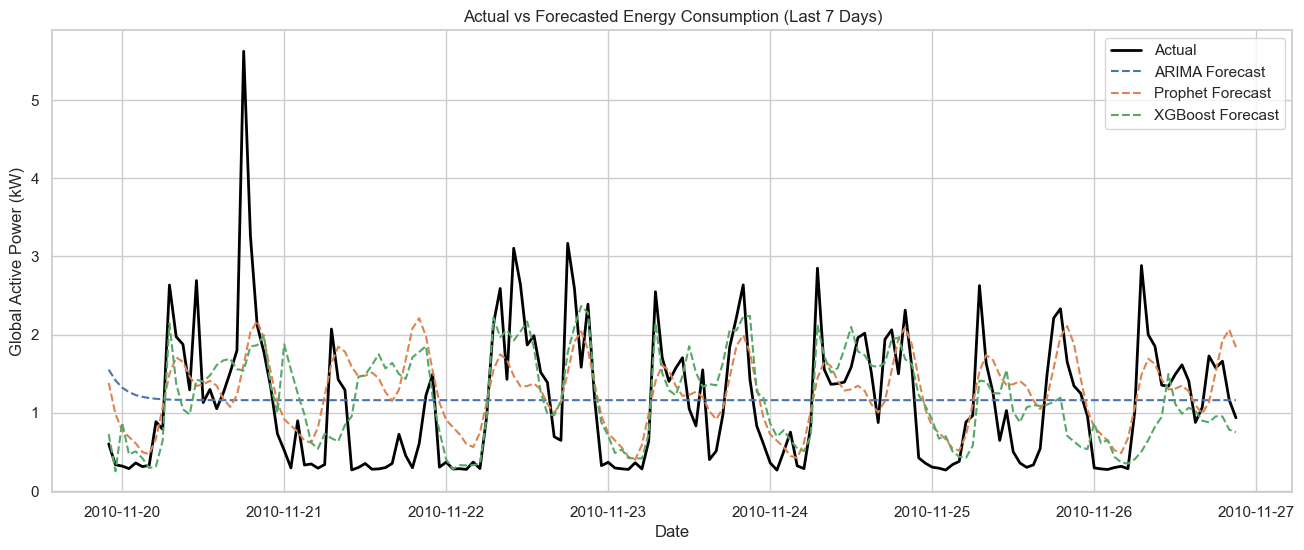

In [20]:
plt.figure(figsize=(16,6))
plt.plot(test.index, test['Global_active_power'], label='Actual', color='black', linewidth=2)
plt.plot(test.index, arima_forecast, label='ARIMA Forecast', linestyle='--')
plt.plot(test.index, prophet_forecast, label='Prophet Forecast', linestyle='--')
plt.plot(test.index, xgb_forecast, label='XGBoost Forecast', linestyle='--')
plt.title("Actual vs Forecasted Energy Consumption (Last 7 Days)")
plt.xlabel("Date")
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.show()

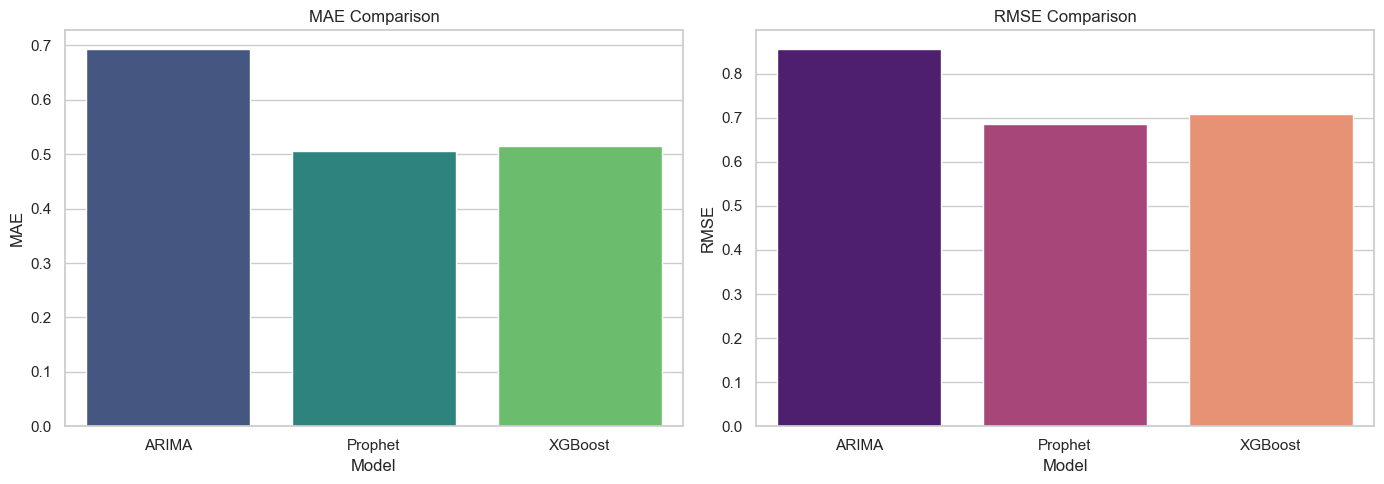

,Model,MAE,RMSE
0,ARIMA,0.692973,0.855547
1,Prophet,0.506138,0.686443
2,XGBoost,0.515636,0.708206


In [21]:
results_df = pd.DataFrame({
    'Model': ['ARIMA', 'Prophet', 'XGBoost'],
    'MAE': [arima_mae, prophet_mae, xgb_mae],
    'RMSE': [arima_rmse, prophet_rmse, xgb_rmse]
})

fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.barplot(x='Model', y='MAE', data=results_df, ax=axes[0], palette='viridis')
axes[0].set_title("MAE Comparison")

sns.barplot(x='Model', y='RMSE', data=results_df, ax=axes[1], palette='magma')
axes[1].set_title("RMSE Comparison")

plt.tight_layout()
plt.show()

results_df